# AI-Based Handwritten Digit Generation Using Generative Adversarial Networks (GAN)

**Module End Project: Generative Deep Learning Applications**

### Problem Statement
Generative AI can create new images that resemble real-world data. This notebook builds a **Generative Adversarial Network (GAN)** using TensorFlow/Keras to generate handwritten digit images similar to the MNIST dataset.

### Objectives
- Understand the basic concept of Generative AI and GANs.
- Preprocess the MNIST image dataset.
- Build Generator and Discriminator networks.
- Train a GAN using adversarial learning.
- Generate new handwritten digit images.
- Analyze GAN training using generated images and loss curves.

### How a GAN works (in short)
A GAN has two networks trained against each other:
- **Generator (G):** takes random noise and tries to turn it into a realistic-looking digit image.
- **Discriminator (D):** looks at an image (real or generated) and tries to say whether it is real or fake.

G tries to fool D, and D tries to catch G. Over many rounds of this "game", G slowly learns to draw digits that look real.


## 1. Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import time
import os

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Load the Dataset

As specified in the project, we use the **MNIST dataset** directly from `tf.keras.datasets`.
We only need the training images — GANs learn the shape of the data distribution, so labels are not required.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images shape: (60000, 28, 28)
Pixel value range before preprocessing: 0 - 255


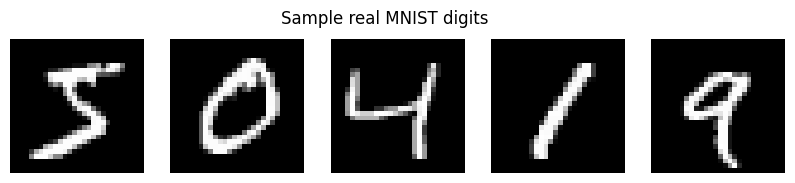

In [2]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

print("Training images shape:", x_train.shape)
print("Pixel value range before preprocessing:", x_train.min(), "-", x_train.max())

# Peek at a few real digits
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i], cmap="gray")
    ax.axis("off")
plt.suptitle("Sample real MNIST digits")
plt.show()


## 3. Preprocess the Data

Two steps, as required:
1. **Normalize** pixel values from `[0, 255]` to `[-1, 1]` (this matches the `tanh` activation used at the Generator's output).
2. **Reshape** each image to `(28, 28, 1)` so it has an explicit channel dimension for the convolutional layers.


In [3]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256
NOISE_DIM = 100

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype("float32")
x_train = (x_train - 127.5) / 127.5  # scale to [-1, 1]

print("New shape:", x_train.shape)
print("New pixel range:", x_train.min(), "-", x_train.max())

train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)


New shape: (60000, 28, 28, 1)
New pixel range: -1.0 - 1.0


## 4. Build the Generator Network

The Generator takes a **100-dimensional random noise vector** and upsamples it step by step into a **28×28×1** grayscale image.

Architecture (as specified): `Dense -> BatchNormalization -> LeakyReLU -> Conv2DTranspose (x2) -> Output (Tanh)`


In [4]:
def build_generator():
    model = tf.keras.Sequential(name="Generator")

    # Dense layer: project noise into a small 7x7x256 feature map
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(NOISE_DIM,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Reshape((7, 7, 256)))

    # Upsample: 7x7 -> 7x7 (refine features)
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsample: 7x7 -> 14x14
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsample: 14x14 -> 28x28, output image with Tanh activation -> range [-1, 1]
    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding="same",
                                      use_bias=False, activation="tanh"))

    return model

generator = build_generator()
generator.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

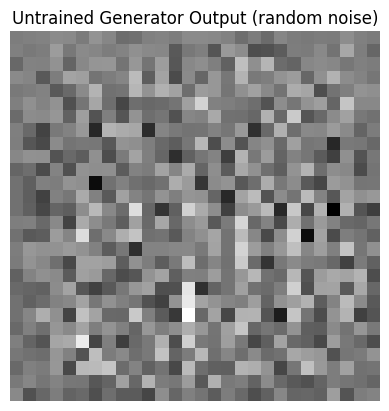

In [5]:
# Quick sanity check: an untrained generator should output pure noise
noise = tf.random.normal([1, NOISE_DIM])
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0], cmap="gray")
plt.title("Untrained Generator Output (random noise)")
plt.axis("off")
plt.show()


## 5. Build the Discriminator Network

The Discriminator is a binary image classifier: it looks at a `28x28x1` image and outputs a single value —
close to **1** if it thinks the image is real, close to **0** if it thinks it's fake.

Architecture (as specified): `Conv2D -> LeakyReLU -> Dropout -> Flatten -> Dense (Sigmoid)`


In [6]:
def build_discriminator():
    model = tf.keras.Sequential(name="Discriminator")

    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding="same",
                             input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same"))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation="sigmoid"))

    return model

discriminator = build_discriminator()
discriminator.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Sanity check: feed the untrained generator's image into the untrained discriminator
decision = discriminator(generated_image)
print("Discriminator output (probability image is real):", decision.numpy())


Discriminator output (probability image is real): [[0.49988964]]


## 6. Loss Function and Optimizers

As specified:
- **Loss:** Binary Cross-Entropy (BCE)
- **Optimizer:** Adam with learning rate `0.0002` and `beta_1 = 0.5` (standard, stable choice for GAN training)


In [8]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    # Real images should be classified as 1, fake images as 0
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    # Generator wants the discriminator to classify fake images as real (1)
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)


## 7. Define a Single Training Step

Each training step:
1. Generates a batch of fake images from random noise.
2. Lets the Discriminator score both real and fake images.
3. Computes losses for both networks.
4. Updates both networks' weights via backpropagation.


In [10]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss


## 8. Training Loop

We train for **20+ epochs** (configurable below). Every few epochs we:
- Save/display a grid of generated digit images (using a **fixed** noise vector, so we can see the same "seed" images improve over time).
- Record the average Generator and Discriminator loss for that epoch (used later to plot the loss curves).


In [11]:
EPOCHS = 20
NUM_EXAMPLES_TO_GENERATE = 16
SHOW_EVERY = 5  # display a sample grid every N epochs

# Fixed seed noise so we can visually track the SAME images improving over training
seed = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, NOISE_DIM])

gen_loss_history = []
disc_loss_history = []

os.makedirs("gan_samples", exist_ok=True)

def generate_and_show_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap="gray")
        plt.axis("off")

    plt.suptitle(f"Generated Digits - Epoch {epoch}")
    plt.savefig(f"gan_samples/epoch_{epoch:03d}.png")
    plt.show()

def train(dataset, epochs):
    for epoch in range(1, epochs + 1):
        start = time.time()

        epoch_gen_loss = []
        epoch_disc_loss = []

        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
            epoch_gen_loss.append(g_loss.numpy())
            epoch_disc_loss.append(d_loss.numpy())

        avg_gen_loss = np.mean(epoch_gen_loss)
        avg_disc_loss = np.mean(epoch_disc_loss)
        gen_loss_history.append(avg_gen_loss)
        disc_loss_history.append(avg_disc_loss)

        print(f"Epoch {epoch}/{epochs}  |  Gen Loss: {avg_gen_loss:.4f}  |  "
              f"Disc Loss: {avg_disc_loss:.4f}  |  Time: {time.time() - start:.1f}s")

        if epoch % SHOW_EVERY == 0 or epoch == epochs:
            generate_and_show_images(generator, epoch, seed)


## 9. Run Training

> **Note:** GAN training is compute-intensive. Running this on a GPU (e.g. Google Colab with a GPU runtime) is
> strongly recommended for the full 20 epochs on the complete 60,000-image dataset. On CPU-only machines, you can
> temporarily reduce `EPOCHS` or use a subset of `train_dataset` while testing your code, then switch back to
> the full settings above for your final submission run.


Epoch 1/20  |  Gen Loss: 0.6611  |  Disc Loss: 1.3167  |  Time: 21.6s
Epoch 2/20  |  Gen Loss: 0.7274  |  Disc Loss: 1.3534  |  Time: 20.5s
Epoch 3/20  |  Gen Loss: 0.7290  |  Disc Loss: 1.3561  |  Time: 12.2s
Epoch 4/20  |  Gen Loss: 0.7509  |  Disc Loss: 1.3337  |  Time: 12.5s
Epoch 5/20  |  Gen Loss: 0.7802  |  Disc Loss: 1.3088  |  Time: 13.2s


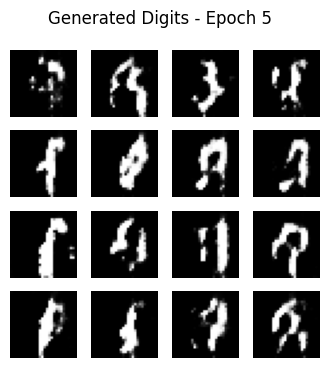

Epoch 6/20  |  Gen Loss: 0.8164  |  Disc Loss: 1.2790  |  Time: 14.2s
Epoch 7/20  |  Gen Loss: 0.8144  |  Disc Loss: 1.2795  |  Time: 14.3s
Epoch 8/20  |  Gen Loss: 0.7945  |  Disc Loss: 1.3073  |  Time: 13.9s
Epoch 9/20  |  Gen Loss: 0.7792  |  Disc Loss: 1.3219  |  Time: 13.3s
Epoch 10/20  |  Gen Loss: 0.7733  |  Disc Loss: 1.3258  |  Time: 13.2s


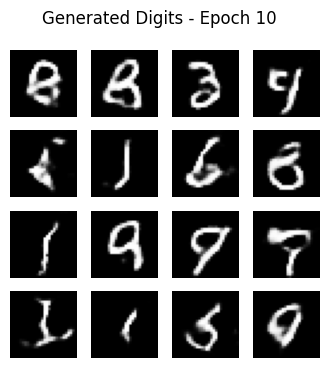

Epoch 11/20  |  Gen Loss: 0.7558  |  Disc Loss: 1.3391  |  Time: 13.2s
Epoch 12/20  |  Gen Loss: 0.7734  |  Disc Loss: 1.3309  |  Time: 13.5s
Epoch 13/20  |  Gen Loss: 0.7589  |  Disc Loss: 1.3356  |  Time: 13.7s
Epoch 14/20  |  Gen Loss: 0.7532  |  Disc Loss: 1.3379  |  Time: 13.7s
Epoch 15/20  |  Gen Loss: 0.7785  |  Disc Loss: 1.3266  |  Time: 13.6s


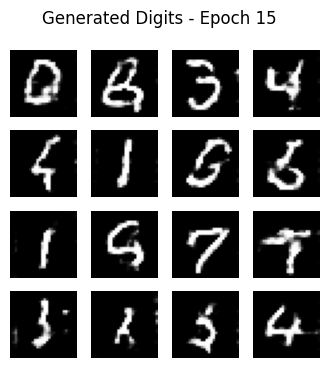

Epoch 16/20  |  Gen Loss: 0.7672  |  Disc Loss: 1.3293  |  Time: 13.5s
Epoch 17/20  |  Gen Loss: 0.7749  |  Disc Loss: 1.3268  |  Time: 13.5s
Epoch 18/20  |  Gen Loss: 0.7780  |  Disc Loss: 1.3254  |  Time: 13.5s
Epoch 19/20  |  Gen Loss: 0.7812  |  Disc Loss: 1.3199  |  Time: 13.5s
Epoch 20/20  |  Gen Loss: 0.7824  |  Disc Loss: 1.3234  |  Time: 13.5s


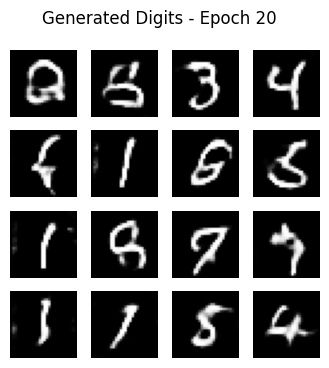

In [12]:
train(train_dataset, EPOCHS)


## 10. Plot Generator and Discriminator Loss Curves

Analyzing the loss curves helps us judge training stability:
- If Discriminator loss collapses to ~0, it has become too strong (Generator can't fool it — "mode collapse" risk).
- If Generator loss keeps rising while Discriminator loss keeps falling, training is imbalanced.
- Healthy GAN training usually shows both losses oscillating and roughly stabilizing, rather than one completely dominating.


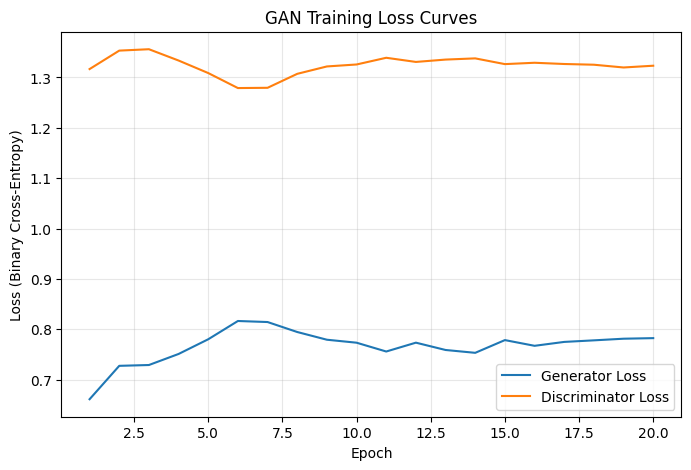

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(gen_loss_history) + 1), gen_loss_history, label="Generator Loss")
plt.plot(range(1, len(disc_loss_history) + 1), disc_loss_history, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (Binary Cross-Entropy)")
plt.title("GAN Training Loss Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("gan_samples/loss_curves.png")
plt.show()


## 11. Final Generated Digit Samples

A final look at a larger grid of freshly generated digits from random noise (not the fixed seed this time),
to evaluate overall generation quality after training.


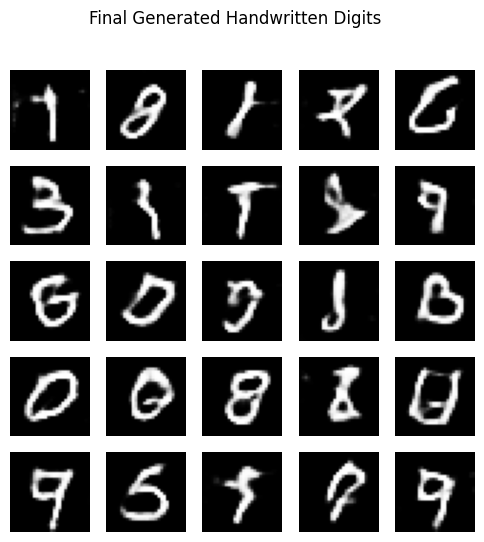

In [14]:
def generate_final_grid(model, n=25):
    noise = tf.random.normal([n, NOISE_DIM])
    predictions = model(noise, training=False)

    grid_size = int(np.sqrt(n))
    fig = plt.figure(figsize=(6, 6))
    for i in range(n):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap="gray")
        plt.axis("off")
    plt.suptitle("Final Generated Handwritten Digits")
    plt.savefig("gan_samples/final_generated_grid.png")
    plt.show()

generate_final_grid(generator, n=25)


## 12. Conclusion / Analysis

- The Generator started by producing random noise and gradually learned to output digit-like shapes as training progressed across epochs.
- The Discriminator's job got harder over time as the Generator improved, which is reflected in the loss curves above.
- Further improvements you could explore: training for more epochs, using label smoothing, adding more Conv2DTranspose/Conv2D layers, or trying a Wasserstein GAN (WGAN) loss for more stable training.
